# Which Machine Learning Model Should You Trust? 🤔 Understanding ML Models Across Datasets 🧠

### A Reproducible Multi-Dataset Machine Learning Benchmark

> **Is there really a "best" machine learning model?**

Random Forests are powerful.  
Gradient Boosting performs exceptionally well on many tabular problems.  
Neural Networks can learn highly complex patterns.  
And sometimes, a simple linear model can still be surprisingly competitive.

But there is a bigger question:

> **Does the best-performing model remain the best when the dataset changes?**


![GIF](https://media1.tenor.com/m/1OknyKzNWsUAAAAd/robot-dies.gif)

Instead of evaluating algorithms on a single dataset, this study takes a broader approach.

We benchmark multiple machine learning algorithms across diverse classification datasets and examine:

- 🎯 Predictive performance
- 🔄 Cross-validation stability
- 🏆 Cross-dataset consistency
- ⚡ Training efficiency
- 📊 Dataset characteristics
- 🔍 Feature-level importance

### 🔬 Research Question

> **How does dataset structure influence the performance, consistency, and computational behaviour of different machine learning algorithms?**

### 🧪 Experimental Journey

**OpenML → Dataset Selection → Dataset Profiling → EDA → Leakage-Safe Preprocessing → Multi-Model Benchmark → Cross-Validation → Performance Analysis → Efficiency Analysis → Explainability → Research Findings**

So, rather than simply asking:

> *"Which model has the highest score?"*

we ask:

> **"Which models perform well, when do they perform well, and what characteristics of the data may explain their behaviour?"**



# 🔬Experiment Overview

Before training a single model, let's define what this experiment is actually trying to discover.

A machine learning model does not exist in isolation.

Its performance depends on the interaction between:

**Model × Dataset × Features × Target Distribution × Computational Constraints**

Therefore, testing one model on one dataset can provide only a very limited view of its capabilities.

This notebook instead evaluates several algorithms across multiple datasets under a common experimental framework.

### 🎯 What We Want to Discover

1. Which models achieve the strongest predictive performance?
2. Which models remain competitive across different datasets?
3. How stable are their results under cross-validation?
4. What is the computational cost of achieving that performance?
5. Are dataset characteristics associated with model performance?
6. What features appear to influence the predictions of the winning models?

> **The objective is not simply to find a winner. It is to understand model behaviour.**

# ⚙️ Reproducibility First

A benchmark is meaningful only when the experiment can be reproduced.

This study therefore establishes a consistent experimental environment before any model is trained.

The notebook uses:

- 🎲 A fixed random seed
- 📊 Consistent train-test splitting
- 🔄 Stratified cross-validation
- 🧩 Unified preprocessing pipelines
- 📏 Consistent evaluation metrics
- ⏱️ Training and prediction-time measurements

The datasets are retrieved programmatically from OpenML, while the machine learning workflow is implemented using Scikit-learn.

> **Every model should compete under the same experimental conditions.**

This makes the comparison more controlled, transparent, and reproducible.

In [ ]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 3
np.random.seed(RANDOM_STATE)
print("Core libraries imported successfully.")

Core libraries imported successfully.


# 🌍One Dataset Is Not Enough

Imagine benchmarking seven algorithms on a single dataset.

One model wins.

Can we now call it the **best machine learning model**?

Not really.

Different datasets can have very different:

- 📦 Sample sizes
- 🔢 Feature dimensions
- 🔤 Categorical structures
- 🎯 Number of target classes
- ⚖️ Class distributions
- 🕳️ Missing values
- 🔠 Feature cardinalities

A model that performs exceptionally well on one dataset may behave very differently on another.

### 📚 Benchmark Dataset Suite

This study therefore uses multiple classification datasets retrieved from **OpenML**.

Each dataset provides a different learning environment, allowing us to investigate whether model performance is consistent or highly dataset-dependent.

> **The real benchmark begins when the data changes.**

In [ ]:
DATASET_REGISTRY = {
    "Adult Income": 1590,
    "Credit-G": 31,
    "Spambase": 44,
    "Diabetes": 37,
    "Bank Marketing": 1461
}

for name, data_id in DATASET_REGISTRY.items():
    print(f"{name}: OpenML ID {data_id}")

Adult Income: OpenML ID 1590
Credit-G: OpenML ID 31
Spambase: OpenML ID 44
Diabetes: OpenML ID 37
Bank Marketing: OpenML ID 1461


# 🤖The Models Enter the Arena

Machine learning algorithms learn in fundamentally different ways.

Some search for linear relationships.

Some rely on neighbourhood similarity.

Some recursively partition the feature space.

Others combine many weak learners into powerful ensembles.

And neural networks learn representations through layers of nonlinear transformations.

### 🧠 Models Evaluated

The benchmark includes models from several algorithmic families:

| Model | Learning Approach |
|---|---|
| 🧱 Dummy Classifier | Baseline |
| 📈 Logistic Regression | Linear modelling |
| 📍 K-Nearest Neighbours | Instance-based learning |
| 🌳 Decision Tree | Tree-based learning |
| 🌲 Random Forest | Bagged ensemble |
| 🚀 HistGradientBoosting | Gradient boosting |
| 🧠 MLP | Neural network |
| ⚡ XGBoost / LightGBM / CatBoost | Advanced boosting |

Optional boosting libraries are included when available in the execution environment.

### ❓ The Question

> **When the data changes, which learning strategy remains competitive?**

In [ ]:
def build_models():
    models = {
        "Dummy": DummyClassifier(strategy="most_frequent"),
        "Logistic Regression": LogisticRegression(max_iter=2500, random_state=RANDOM_STATE),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
        "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
        "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
        "MLP": MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=400, random_state=RANDOM_STATE)
    }
    try:
        from xgboost import XGBClassifier
        models["XGBoost"] = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.08, subsample=0.9, colsample_bytree=0.9, random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=-1)
    except Exception as exc:
        print("XGBoost unavailable:", exc)
    try:
        from lightgbm import LGBMClassifier
        models["LightGBM"] = LGBMClassifier(n_estimators=200, learning_rate=0.08, random_state=RANDOM_STATE, verbosity=-1)
    except Exception as exc:
        print("LightGBM unavailable:", exc)
    try:
        from catboost import CatBoostClassifier
        models["CatBoost"] = CatBoostClassifier(iterations=200, learning_rate=0.08, random_seed=RANDOM_STATE, verbose=0)
    except Exception as exc:
        print("CatBoost unavailable:", exc)
    return models

MODELS = build_models()
print(f"{len(MODELS)} models available:")
for name in MODELS:
    print("-", name)

CatBoost unavailable: No module named 'catboost'
9 models available:
- Dummy
- Logistic Regression
- KNN
- Decision Tree
- Random Forest
- Hist Gradient Boosting
- MLP
- XGBoost
- LightGBM


# 🌐Getting the Data — Reproducibly

Rather than manually downloading and preparing individual datasets, this experiment retrieves them programmatically from OpenML.

OpenML provides machine-readable datasets and metadata that make programmatic benchmarking practical and reproducible.

For each dataset, the pipeline:

1. Requests the dataset from OpenML
2. Validates the returned feature and target data
3. Encodes the target labels consistently
4. Stores successfully retrieved datasets
5. Records failed retrievals without stopping the entire experiment

A retry mechanism is also used to handle temporary retrieval failures.

> **A reproducible benchmark should not depend on manually prepared files.**

In [ ]:
def fetch_openml_safely(dataset_name, data_id, retries=2):
    last_error = None
    for attempt in range(1, retries + 1):
        try:
            print(f"Fetching {dataset_name} (ID {data_id}), attempt {attempt}/{retries}...")
            bunch = fetch_openml(data_id=data_id, as_frame=True, parser="auto")
            X = bunch.data.copy()
            y_raw = pd.Series(bunch.target).copy()
            if X.empty or y_raw.empty:
                raise ValueError("Empty features or target returned by OpenML.")
            encoder = LabelEncoder()
            y = pd.Series(encoder.fit_transform(y_raw.astype(str)), index=y_raw.index, name="target")
            return {"name":dataset_name,"data_id":data_id,"bunch":bunch,"X":X,"y":y,"label_encoder":encoder,"original_target":y_raw}
        except Exception as exc:
            last_error = exc
            print("Retrieval failed:", exc)
            if attempt < retries:
                time.sleep(2)
    return {"name":dataset_name,"data_id":data_id,"error":str(last_error)}

In [ ]:
DATASETS = {}
FAILED_DATASETS = {}
for dataset_name, data_id in DATASET_REGISTRY.items():
    result = fetch_openml_safely(dataset_name, data_id)
    if "X" in result:
        DATASETS[dataset_name] = result
    else:
        FAILED_DATASETS[dataset_name] = result.get("error", "Unknown error")

print("Successful datasets:", list(DATASETS.keys()))
if FAILED_DATASETS:
    print("Failed datasets:")
    for name, error in FAILED_DATASETS.items():
        print(f"- {name}: {error}")
if len(DATASETS) < 2:
    raise RuntimeError("Fewer than two datasets were retrieved. Enable Internet access in Kaggle.")

Fetching Adult Income (ID 1590), attempt 1/2...
Fetching Credit-G (ID 31), attempt 1/2...
Fetching Spambase (ID 44), attempt 1/2...
Fetching Diabetes (ID 37), attempt 1/2...
Fetching Bank Marketing (ID 1461), attempt 1/2...
Successful datasets: ['Adult Income', 'Credit-G', 'Spambase', 'Diabetes', 'Bank Marketing']


# 🔎Before We Train Anything...

Here is an important question:

> **What does each dataset actually look like?**

Before comparing algorithms, we first create a structural profile of every dataset.

The profiling stage examines:

- 📦 Number of samples
- 🔢 Number of features
- 🔢 Numerical features
- 🔤 Categorical features
- 🎯 Number of target classes
- 🕳️ Missing-value percentage
- ♻️ Duplicate percentage
- ⚖️ Class imbalance
- 🔠 High-cardinality categorical features

This gives every dataset its own **data fingerprint**.

Later, we can connect these fingerprints with model performance and ask:

> **Can the structure of a dataset help explain which models perform well?**

In [ ]:
def profile_dataset(dataset_name, X, y):
    numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
    categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()
    total_cells = X.shape[0] * X.shape[1]
    missing_pct = (X.isna().sum().sum() / total_cells * 100) if total_cells else 0
    duplicate_pct = (X.duplicated().sum() / len(X) * 100) if len(X) else 0
    class_counts = y.value_counts()
    imbalance_ratio = class_counts.max() / class_counts.min() if len(class_counts) > 1 else np.nan
    high_cardinality = [c for c in categorical_cols if X[c].nunique(dropna=True) > 20]
    return {
        "Dataset": dataset_name,
        "Samples": len(X),
        "Raw Features": X.shape[1],
        "Numerical Features": len(numeric_cols),
        "Categorical Features": len(categorical_cols),
        "Classes": y.nunique(),
        "Missing %": missing_pct,
        "Duplicate %": duplicate_pct,
        "Imbalance Ratio": imbalance_ratio,
        "High-Cardinality Features": len(high_cardinality)
    }

profile_df = pd.DataFrame([profile_dataset(name, d["X"], d["y"]) for name, d in DATASETS.items()])
display(profile_df.round(3))

,Dataset,Samples,Raw Features,Numerical Features,Categorical Features,Classes,Missing %,Duplicate %,Imbalance Ratio,High-Cardinality Features
0,Adult Income,48842,14,6,8,2,0.945,0.117,3.179,1
1,Credit-G,1000,20,7,13,2,0.000,0.000,2.333,0
2,Spambase,4601,57,57,0,2,0.000,8.563,1.538,0
3,Diabetes,768,8,8,0,2,0.000,0.000,1.866,0
4,Bank Marketing,45211,16,7,9,2,0.000,0.000,7.548,0


# 📊 A First Look at the Data

Before asking the models to learn, let's understand the problems they are being asked to solve.

### 📦 How large are the datasets?

Dataset size can influence the amount of information available to a model as well as its computational requirements.

### ⚖️ How balanced are the target classes?

Class imbalance can make aggregate performance measures misleading, particularly when minority classes are predicted poorly.

Therefore, we visualise both dataset scale and class distributions before moving into model benchmarking.

> **Good machine learning starts with understanding the data — not with fitting a model.**

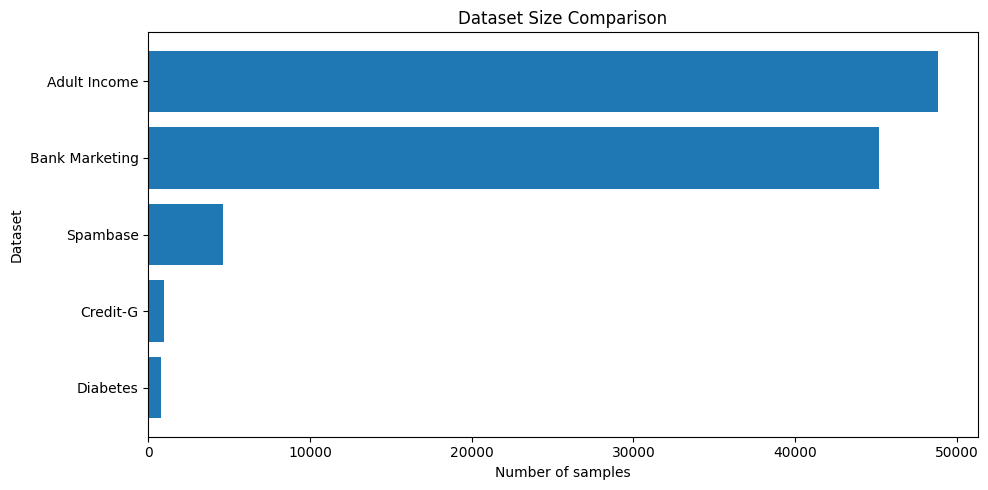

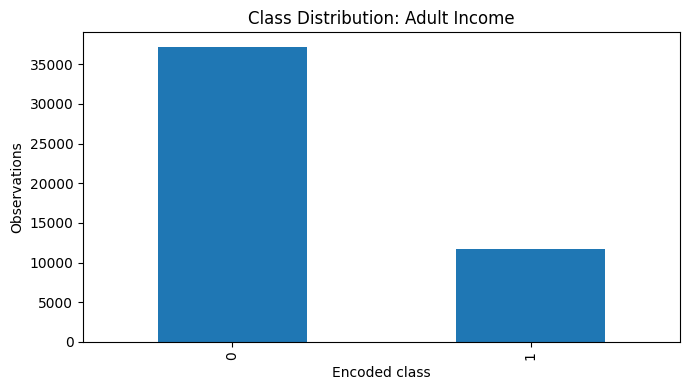

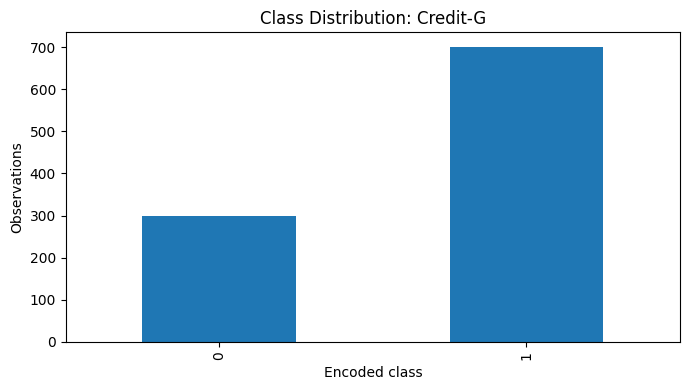

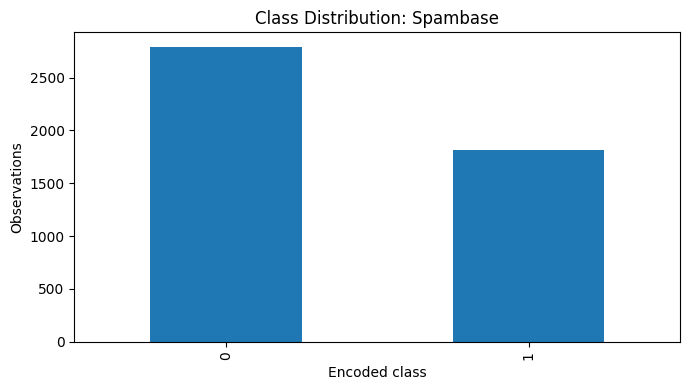

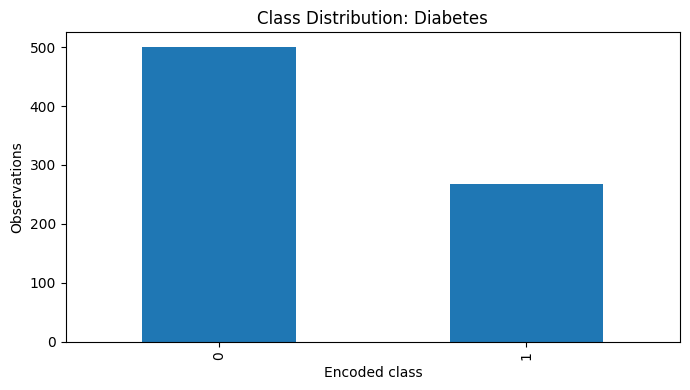

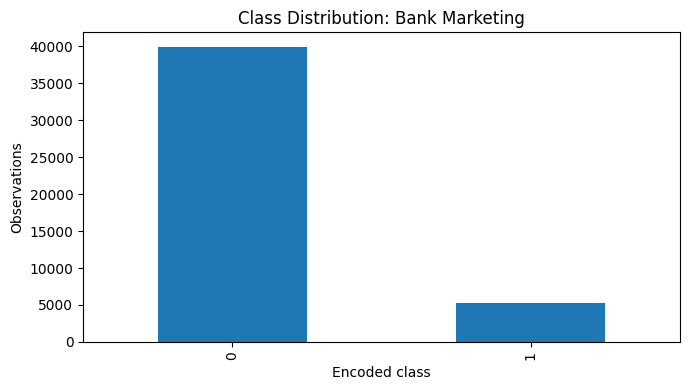

In [ ]:
plot_df = profile_df.sort_values("Samples")
plt.figure(figsize=(10,5))
plt.barh(plot_df["Dataset"], plot_df["Samples"])
plt.xlabel("Number of samples")
plt.ylabel("Dataset")
plt.title("Dataset Size Comparison")
plt.tight_layout()
plt.show()

for dataset_name, dataset_info in DATASETS.items():
    y = dataset_info["y"]
    plt.figure(figsize=(7,4))
    y.value_counts().sort_index().plot(kind="bar")
    plt.title(f"Class Distribution: {dataset_name}")
    plt.xlabel("Encoded class")
    plt.ylabel("Observations")
    plt.tight_layout()
    plt.show()

# 🛡️ No Data Leakage Allowed

One of the easiest ways to obtain misleading machine learning results is through **data leakage**.

If information from the evaluation data influences preprocessing, the model can indirectly gain access to information that should have remained unseen.

To minimise this risk, preprocessing is integrated directly into the machine learning pipeline.

### 🔢 Numerical Features

**Missing values → Median Imputation → Standardisation**

### 🔤 Categorical Features

**Missing values → Most-Frequent Imputation → One-Hot Encoding**

By placing transformations inside the pipeline, preprocessing becomes part of the model-fitting procedure rather than a separate operation performed on the entire dataset.

> **A fair benchmark begins with a clean experimental boundary between training and evaluation data.**

In [ ]:
def build_preprocessor(X):
    numerical = X.select_dtypes(include=np.number).columns.tolist()
    categorical = X.select_dtypes(exclude=np.number).columns.tolist()
    numeric_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
    categorical_pipeline = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
    return ColumnTransformer([("numeric", numeric_pipeline, numerical), ("categorical", categorical_pipeline, categorical)], remainder="drop")

In [ ]:
def safe_roc_auc(y_true, pipeline, X_test):
    try:
        probabilities = pipeline.predict_proba(X_test)
        if len(np.unique(y_true)) == 2:
            return roc_auc_score(y_true, probabilities[:,1])
        return roc_auc_score(y_true, probabilities, multi_class="ovr", average="weighted")
    except Exception:
        return np.nan

def evaluate_single_model(dataset_name, model_name, model, X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)
    pipeline = Pipeline([("preprocessing", build_preprocessor(X)), ("model", clone(model))])
    start = time.perf_counter(); pipeline.fit(X_train, y_train); training_time = time.perf_counter() - start
    start = time.perf_counter(); predictions = pipeline.predict(X_test); prediction_time = time.perf_counter() - start
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    cv_scores = cross_val_score(pipeline, X, y, scoring="f1_weighted", cv=cv, n_jobs=-1)
    result = {
        "Dataset":dataset_name, "Model":model_name,
        "Accuracy":accuracy_score(y_test,predictions),
        "Precision":precision_score(y_test,predictions,average="weighted",zero_division=0),
        "Recall":recall_score(y_test,predictions,average="weighted",zero_division=0),
        "F1":f1_score(y_test,predictions,average="weighted",zero_division=0),
        "ROC-AUC":safe_roc_auc(y_test,pipeline,X_test),
        "CV F1 Mean":cv_scores.mean(), "CV F1 Std":cv_scores.std(),
        "Training Time":training_time, "Prediction Time":prediction_time
    }
    return result, pipeline, X_test, y_test

# ⚔️ The Benchmark Begins

Now the real experiment begins.

Every available model is evaluated on every successfully retrieved dataset using the same general evaluation framework.

### 📏 What Do We Measure?

Instead of relying on a single metric, we collect multiple perspectives:

- 🎯 Accuracy
- Precision
- Recall
- ⭐ Weighted F1-score
- 📈 ROC-AUC
- 🔄 Cross-validation F1-score
- 📉 Cross-validation variability
- ⏱️ Training time
- ⚡ Prediction time

This is important because predictive performance and computational efficiency are not the same thing.

A model that achieves a slightly higher F1-score but requires substantially more computation tells a different story from a model that achieves almost the same performance much faster.

> **The benchmark is not looking for a single number. It is building a profile of each model.**

In [ ]:
benchmark_results = []
benchmark_failures = []
trained_artifacts = {}

for dataset_name, dataset_info in DATASETS.items():
    X, y = dataset_info["X"], dataset_info["y"]
    print("\n" + "="*80)
    print("DATASET:", dataset_name)
    print("="*80)
    for model_name, model in MODELS.items():
        print("Training", model_name)
        try:
            result, pipeline, X_test, y_test = evaluate_single_model(dataset_name, model_name, model, X, y)
            benchmark_results.append(result)
            trained_artifacts[(dataset_name, model_name)] = {"pipeline":pipeline,"X_test":X_test,"y_test":y_test}
            print(f"  F1={result['F1']:.4f} | CV={result['CV F1 Mean']:.4f} | Train={result['Training Time']:.3f}s")
        except Exception as exc:
            benchmark_failures.append({"Dataset":dataset_name,"Model":model_name,"Error":str(exc)})
            print("  [FAILED]", exc)

results_df = pd.DataFrame(benchmark_results)
failure_df = pd.DataFrame(benchmark_failures)
if results_df.empty:
    raise RuntimeError("No model completed successfully.")
print("Benchmark complete.")


DATASET: Adult Income
Training Dummy
  F1=0.6573 | CV=0.6573 | Train=0.750s
Training Logistic Regression
  F1=0.8462 | CV=0.8452 | Train=3.338s
Training KNN
  F1=0.8308 | CV=0.8294 | Train=0.383s
Training Decision Tree
  F1=0.8146 | CV=0.8171 | Train=1.164s
Training Random Forest
  F1=0.8557 | CV=0.8512 | Train=13.771s
Training Hist Gradient Boosting
  F1=0.8707 | CV=0.8692 | Train=4.563s
Training MLP
  F1=0.8198 | CV=0.8166 | Train=271.418s
Training XGBoost
  F1=0.8718 | CV=0.8693 | Train=4.097s
Training LightGBM
  F1=0.8689 | CV=0.8704 | Train=1.235s

DATASET: Credit-G
Training Dummy
  F1=0.5765 | CV=0.5765 | Train=0.020s
Training Logistic Regression
  F1=0.6995 | CV=0.7323 | Train=0.036s
Training KNN
  F1=0.6972 | CV=0.7054 | Train=0.018s
Training Decision Tree
  F1=0.6474 | CV=0.6558 | Train=0.027s
Training Random Forest
  F1=0.7375 | CV=0.7316 | Train=0.560s
Training Hist Gradient Boosting
  F1=0.7181 | CV=0.7366 | Train=0.356s
Training MLP
  F1=0.7000 | CV=0.7304 | Train=1.345s


# 🔄 Is the Result Stable?

A model can perform well on one particular train-test split simply because of how the data happened to be divided.

So we need another question:

> **Would the model perform similarly if the data were split differently?**

This is where cross-validation becomes useful.

The training data is repeatedly divided into folds, allowing the model to be trained and evaluated across multiple partitions.

We therefore examine both:

**Mean Cross-Validation F1 → Typical Performance**

and

**Cross-Validation Standard Deviation → Performance Stability**

A high average score with large variation can tell a very different story from a similarly high score with low variation.

> **A strong model should ideally perform well — and remain reasonably stable.**

In [ ]:
results_ranked = results_df.sort_values(["Dataset","F1"], ascending=[True,False]).reset_index(drop=True)
display(results_ranked.round(4))
if not failure_df.empty:
    print("Failures:")
    display(failure_df)

best_per_dataset = (results_df.sort_values(["Dataset","F1"], ascending=[True,False]).groupby("Dataset", as_index=False).first())
display(best_per_dataset[["Dataset","Model","Accuracy","Precision","Recall","F1","ROC-AUC","CV F1 Mean","CV F1 Std","Training Time"]].round(4))

,Dataset,Model,Accuracy,Precision,Recall,F1,ROC-AUC,CV F1 Mean,CV F1 Std,Training Time,Prediction Time
0,Adult Income,XGBoost,0.8762,0.8719,0.8762,0.8718,0.9301,0.8693,0.0008,4.0972,0.0803
1,Adult Income,Hist Gradient Boosting,0.8747,0.8703,0.8747,0.8707,0.9295,0.8692,0.0013,4.5626,0.2935
2,Adult Income,LightGBM,0.8732,0.8686,0.8732,0.8689,0.9292,0.8704,0.0013,1.2346,0.1520
3,Adult Income,Random Forest,0.8595,0.8544,0.8595,0.8557,0.9055,0.8512,0.0013,13.7710,0.4009
4,Adult Income,Logistic Regression,0.8524,0.8456,0.8524,0.8462,0.9042,0.8452,0.0017,3.3382,0.1540
5,Adult Income,KNN,0.8337,0.8290,0.8337,0.8308,0.8548,0.8294,0.0012,0.3834,6.2894
6,Adult Income,MLP,0.8219,0.8181,0.8219,0.8198,0.8652,0.8166,0.0059,271.4178,0.0848
7,Adult Income,Decision Tree,0.8141,0.8152,0.8141,0.8146,0.7475,0.8171,0.0037,1.1635,0.0345
8,Adult Income,Dummy,0.7607,0.5786,0.7607,0.6573,0.5000,0.6573,0.0000,0.7497,0.0526
9,Bank Marketing,LightGBM,0.9091,0.9007,0.9091,0.9033,0.9345,0.9035,0.0022,1.0197,0.1346


,Dataset,Model,Accuracy,Precision,Recall,F1,ROC-AUC,CV F1 Mean,CV F1 Std,Training Time
0,Adult Income,XGBoost,0.8762,0.8719,0.8762,0.8718,0.9301,0.8693,0.0008,4.0972
1,Bank Marketing,LightGBM,0.9091,0.9007,0.9091,0.9033,0.9345,0.9035,0.0022,1.0197
2,Credit-G,XGBoost,0.7600,0.7493,0.7600,0.7516,0.7670,0.7533,0.0235,0.2265
3,Diabetes,XGBoost,0.7532,0.7513,0.7532,0.7521,0.8261,0.7539,0.0039,0.2461
4,Spambase,LightGBM,0.9501,0.9501,0.9501,0.9501,0.9865,0.9543,0.0033,0.7637


# 🏆 And We Have Our First Winners...

The benchmark results are now consolidated into a common results table.

For each dataset, models are ranked according to their weighted F1-score.

But there is an important distinction:

> **Winning one dataset does not make a model the best model overall.**

A model may dominate one dataset and struggle on another.

Another model may never achieve the absolute highest score but consistently remain near the top.

That second model could be far more interesting from a generalisation and robustness perspective.

So let's move beyond individual victories.

# 🔥 One Model. Many Datasets.

A traditional leaderboard shows who came first.

A heatmap shows the **entire competition**.

Here we compare:

**Models × Datasets × Weighted F1-score**

Look across a row:

> Does the model remain strong when the dataset changes?

Look down a column:

> Do several algorithms perform similarly on the same problem?

The heatmap makes these patterns visible immediately.

### 🧠 What Are We Looking For?

- Consistent high performance
- Dataset-specific strengths
- Sudden performance drops
- Groups of models behaving similarly

> **Consistency can be more informative than a single record-breaking score.**

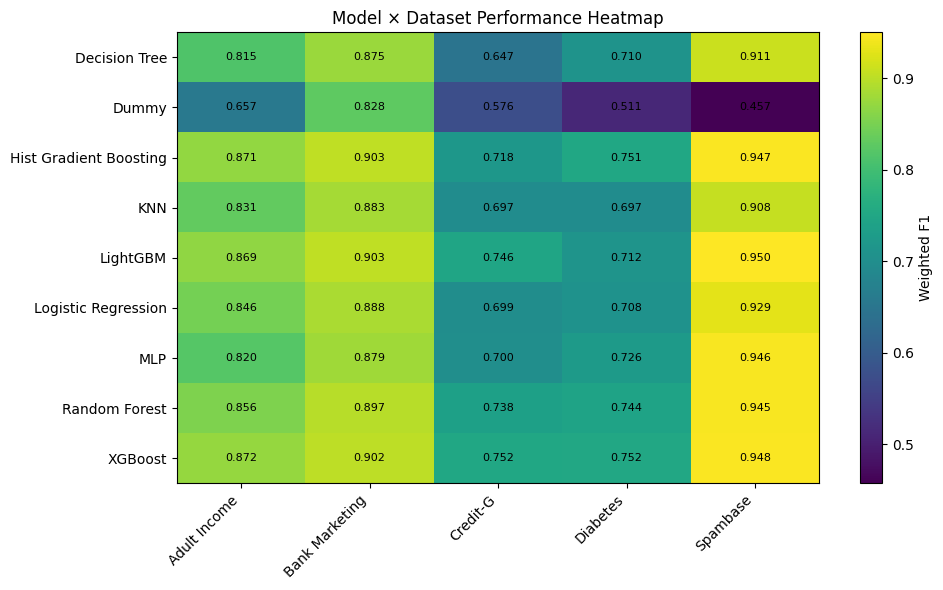

In [ ]:
f1_matrix = results_df.pivot_table(index="Model", columns="Dataset", values="F1", aggfunc="mean")
plt.figure(figsize=(max(10, len(f1_matrix.columns)*2), max(6, len(f1_matrix.index)*0.6)))
img = plt.imshow(f1_matrix.values, aspect="auto")
plt.colorbar(img, label="Weighted F1")
plt.xticks(range(len(f1_matrix.columns)), f1_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(f1_matrix.index)), f1_matrix.index)
plt.title("Model × Dataset Performance Heatmap")
for r in range(f1_matrix.shape[0]):
    for c in range(f1_matrix.shape[1]):
        v = f1_matrix.iloc[r,c]
        if pd.notna(v):
            plt.text(c,r,f"{v:.3f}",ha="center",va="center",fontsize=8)
plt.tight_layout(); plt.show()

Just saying hi for still being in this notebook!


![GIF](https://media1.tenor.com/m/3JL4jb4EKDoAAAAC/jordi-baste-tv3.gif)


This becomes more interesting from now!

# 🧠 Who Is Actually Consistent?

Consider two models:

**Model A**  
🥇 Wins several datasets spectacularly  
📉 Performs poorly on others

**Model B**  
📈 Never achieves the absolute highest score  
🏆 Remains near the top across almost every dataset

Which model would you trust more on a completely new problem?

To investigate this, we compare:

- Mean F1-score
- F1-score variability
- Mean cross-validation F1
- Average training time
- Mean dataset rank
- Rank variability
- Number of datasets evaluated

### 🎯 The Objective

Identify algorithms that are not simply **excellent somewhere**, but **reliably competitive across different data environments**.

> **A consistent model may be more valuable than a model with occasional spectacular wins.**

,Model,Mean_F1,F1_Std,Mean_CV_F1,Mean_Training_Time,Mean_Rank,Rank_Std,Datasets_Evaluated
8,XGBoost,0.8451,0.0893,0.8463,1.8223,1.6,0.8944,5
4,LightGBM,0.8360,0.1027,0.8418,0.6521,2.4,1.6733,5
2,Hist Gradient Boosting,0.8378,0.0988,0.8410,1.6750,2.6,0.8944,5
7,Random Forest,0.8359,0.0926,0.8374,5.4748,3.8,0.8367,5
6,MLP,0.8142,0.1029,0.8165,91.2074,5.4,1.5166,5
5,Logistic Regression,0.8143,0.1050,0.8302,0.8159,5.8,0.8367,5
3,KNN,0.8032,0.1008,0.8106,0.1321,7.0,1.0000,5
0,Decision Tree,0.7917,0.1109,0.7917,0.4149,7.4,0.8944,5
1,Dummy,0.6061,0.1449,0.6065,0.1989,9.0,0.0000,5


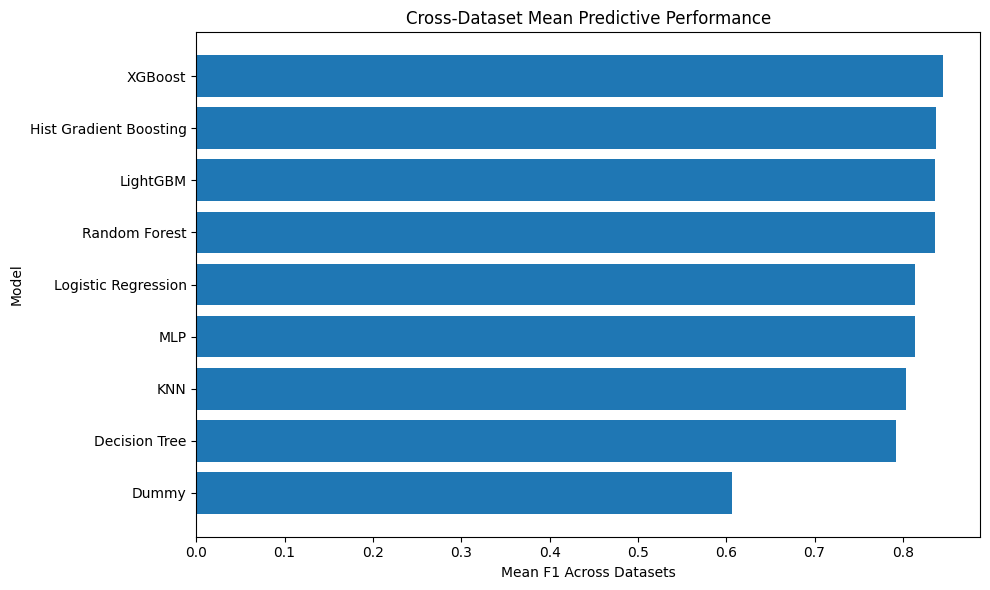

In [ ]:
ranked = results_df.copy()
ranked["Dataset Rank"] = ranked.groupby("Dataset")["F1"].rank(ascending=False, method="average")
model_consistency = (ranked.groupby("Model").agg(
    Mean_F1=("F1","mean"),
    F1_Std=("F1","std"),
    Mean_CV_F1=("CV F1 Mean","mean"),
    Mean_Training_Time=("Training Time","mean"),
    Mean_Rank=("Dataset Rank","mean"),
    Rank_Std=("Dataset Rank","std"),
    Datasets_Evaluated=("Dataset","nunique")
).reset_index().sort_values(["Mean_Rank","Mean_F1"], ascending=[True,False]))
display(model_consistency.round(4))

plot_df = model_consistency.sort_values("Mean_F1")
plt.figure(figsize=(10,6))
plt.barh(plot_df["Model"], plot_df["Mean_F1"])
plt.xlabel("Mean F1 Across Datasets")
plt.ylabel("Model")
plt.title("Cross-Dataset Mean Predictive Performance")
plt.tight_layout(); plt.show()

# ⚡ Accuracy Has a Price

Predictive performance is only one side of model selection.

The other side is computational cost.

A model may achieve a slightly higher score while requiring considerably more training time.

So we ask:

> **How much computation are we paying for the performance we gain?**

The analysis compares:

**Mean F1-score ↔ Mean Training Time**

This allows us to identify potential performance-efficiency trade-offs.

### 💡 Why Does This Matter?

In practical machine learning systems, computational resources, latency, scalability, and retraining frequency can all influence the choice of algorithm.

> **The most accurate model is not automatically the most practical model.**

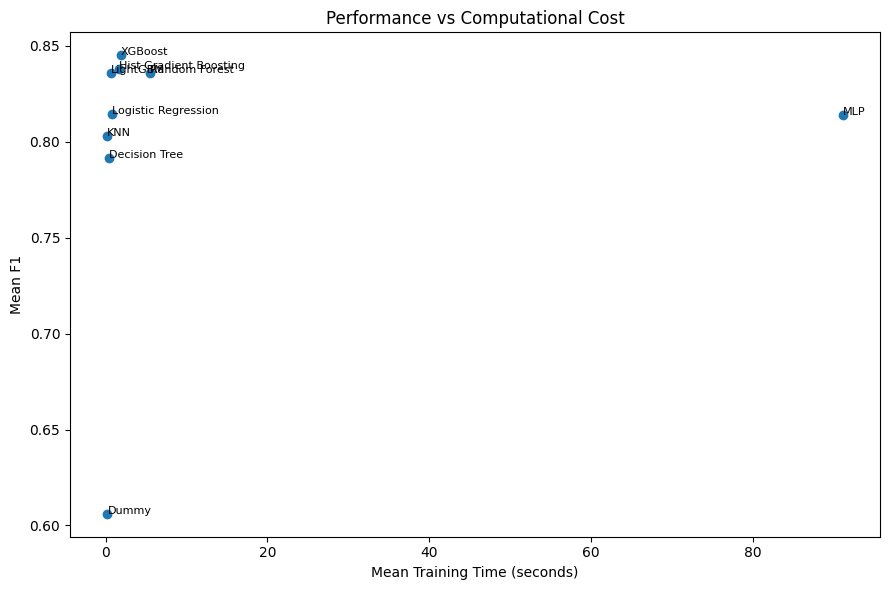

,Model,Mean_F1,Mean_Training_Time,Mean_Prediction_Time
8,XGBoost,0.8451,1.8223,0.0507
2,Hist Gradient Boosting,0.8378,1.6750,0.0979
4,LightGBM,0.8360,0.6521,0.0662
7,Random Forest,0.8359,5.4748,0.2176
5,Logistic Regression,0.8143,0.8159,0.0588
6,MLP,0.8142,91.2074,0.0379
3,KNN,0.8032,0.1321,1.9011
0,Decision Tree,0.7917,0.4149,0.0170
1,Dummy,0.6061,0.1989,0.0210


In [ ]:
efficiency_df = results_df.groupby("Model").agg(Mean_F1=("F1","mean"), Mean_Training_Time=("Training Time","mean"), Mean_Prediction_Time=("Prediction Time","mean")).reset_index()
plt.figure(figsize=(9,6))
plt.scatter(efficiency_df["Mean_Training_Time"], efficiency_df["Mean_F1"])
for _, row in efficiency_df.iterrows():
    plt.annotate(row["Model"], (row["Mean_Training_Time"], row["Mean_F1"]), fontsize=8)
plt.xlabel("Mean Training Time (seconds)")
plt.ylabel("Mean F1")
plt.title("Performance vs Computational Cost")
plt.tight_layout(); plt.show()
display(efficiency_df.sort_values("Mean_F1", ascending=False).round(4))

# 🧬 Can the Dataset Explain the Winner?

Now we reach one of the most interesting questions in this study.

We know **which models performed well**.

But can we understand **why their performance changed across datasets?**

Perhaps dataset size matters.

Perhaps feature dimensionality matters.

Perhaps categorical complexity matters.

Perhaps class imbalance changes the competitive landscape.

We therefore combine dataset profiles with benchmark results and investigate relationships between dataset characteristics and model performance.

### 🔬 Characteristics Considered

- Number of samples
- Number of features
- Numerical/categorical composition
- Number of classes
- Missing values
- Duplicate observations
- Class imbalance
- Categorical complexity

> **The goal is not to claim causality. It is to discover patterns that deserve deeper investigation.**

In [ ]:
analysis_df = results_df.merge(profile_df, on="Dataset", how="left")
characteristic_columns = ["Samples","Raw Features","Numerical Features","Categorical Features","Classes","Missing %","Duplicate %","Imbalance Ratio","High-Cardinality Features"]
correlation_rows = []
for model_name, group in analysis_df.groupby("Model"):
    row = {"Model":model_name}
    for characteristic in characteristic_columns:
        valid = group[[characteristic,"F1"]].dropna()
        row[f"{characteristic} ↔ F1"] = valid[characteristic].corr(valid["F1"]) if len(valid) >= 3 and valid[characteristic].nunique() > 1 else np.nan
    correlation_rows.append(row)
characteristic_correlation_df = pd.DataFrame(correlation_rows)
display(characteristic_correlation_df.round(3))

,Model,Samples ↔ F1,Raw Features ↔ F1,Numerical Features ↔ F1,Categorical Features ↔ F1,Classes ↔ F1,Missing % ↔ F1,Duplicate % ↔ F1,Imbalance Ratio ↔ F1,High-Cardinality Features ↔ F1
0,Decision Tree,0.478,0.569,0.591,-0.366,NaN,0.116,0.605,0.365,0.116
1,Dummy,0.822,-0.493,-0.586,0.603,NaN,0.198,-0.574,0.958,0.198
2,Hist Gradient Boosting,0.497,0.600,0.603,-0.311,NaN,0.186,0.621,0.329,0.186
3,KNN,0.529,0.592,0.564,-0.187,NaN,0.153,0.584,0.412,0.153
4,LightGBM,0.492,0.655,0.604,-0.126,NaN,0.179,0.625,0.343,0.179
5,Logistic Regression,0.505,0.616,0.598,-0.236,NaN,0.170,0.617,0.358,0.170
6,MLP,0.358,0.702,0.704,-0.358,NaN,0.030,0.717,0.277,0.030
7,Random Forest,0.445,0.664,0.647,-0.266,NaN,0.119,0.665,0.321,0.119
8,XGBoost,0.475,0.651,0.628,-0.237,NaN,0.168,0.648,0.320,0.168


# 📈 Does More Data Mean Better Performance?

We often hear:

> **"More data leads to better machine learning."**

But does a larger dataset necessarily produce a higher-performing model?

To explore this, we compare:

**Dataset Size → Best F1-score achieved**

Each point represents one dataset.

The analysis provides a simple visual test of whether larger datasets appear to be associated with stronger benchmark performance.

However, this should be interpreted cautiously.

A relationship between two variables does not establish that one causes the other.

> **Sometimes the most interesting result is the question that the graph creates.**

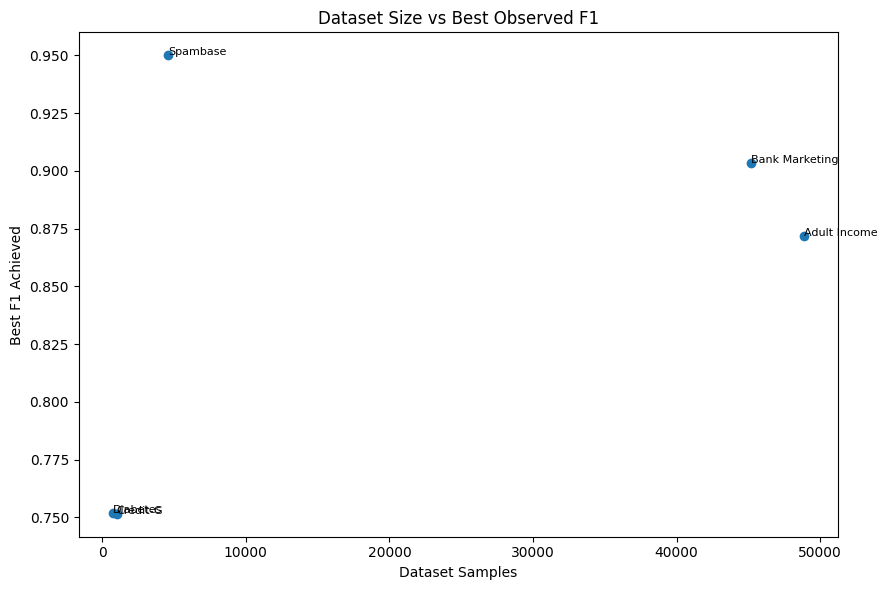

In [ ]:
winner_characteristics = best_per_dataset.merge(profile_df, on="Dataset", how="left")
plt.figure(figsize=(9,6))
plt.scatter(winner_characteristics["Samples"], winner_characteristics["F1"])
for _, row in winner_characteristics.iterrows():
    plt.annotate(row["Dataset"], (row["Samples"], row["F1"]), fontsize=8)
plt.xlabel("Dataset Samples")
plt.ylabel("Best F1 Achieved")
plt.title("Dataset Size vs Best Observed F1")
plt.tight_layout(); plt.show()

# 🧩 Where Does the Winner Actually Make Mistakes?

A single F1-score compresses thousands of predictions into one number.

But it does not tell us **where those mistakes occur**.

For the best-performing model on each dataset, we therefore examine its confusion matrix.

This allows us to investigate:

- Which classes are predicted correctly?
- Which classes are confused?
- Are errors concentrated in particular classes?
- Does strong overall performance hide weaknesses for specific categories?

> **A model's mistakes can reveal information that a leaderboard cannot.** *italicized text*

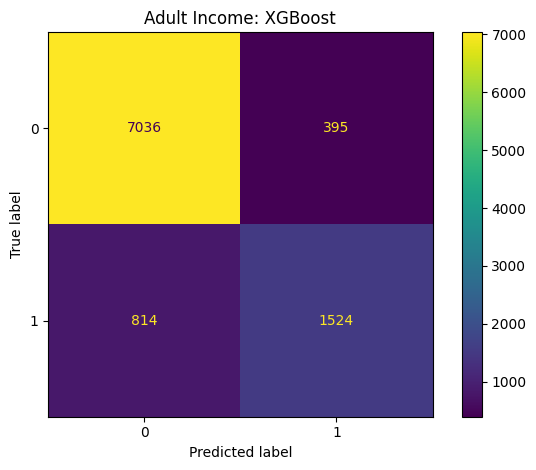

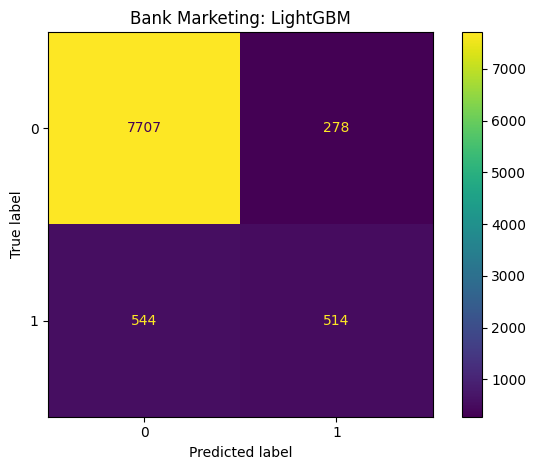

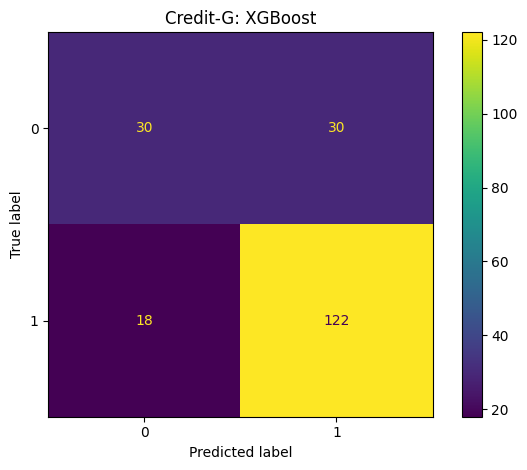

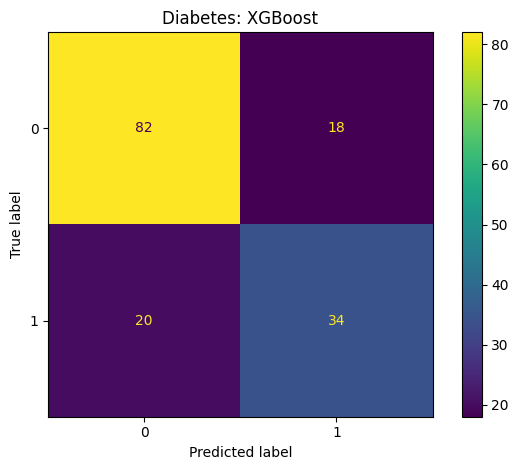

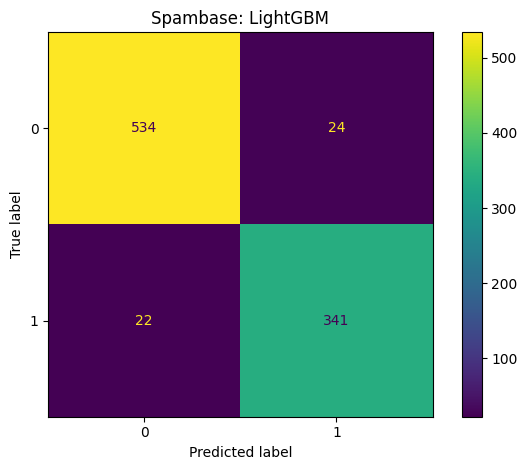

In [ ]:
for _, row in best_per_dataset.iterrows():
    key = (row["Dataset"], row["Model"])
    artifact = trained_artifacts.get(key)
    if artifact is None: continue
    predictions = artifact["pipeline"].predict(artifact["X_test"])
    ConfusionMatrixDisplay.from_predictions(artifact["y_test"], predictions)
    plt.title(f"{row['Dataset']}: {row['Model']}")
    plt.tight_layout(); plt.show()

# 🔍 What Is Driving the Predictions?

Finding the winning model is only half of the story.

A benchmark can tell us:

> **"This model performs best."**

But a deeper analysis asks:

> **"Which features are contributing to its predictive performance?"**

To investigate this, we use **Permutation Feature Importance**.

The idea is intuitive:

1. Measure the model's baseline performance.
2. Randomly shuffle one feature.
3. Measure the performance again.
4. Observe how much the score changes.
5. Repeat across features.

If disrupting a feature causes a large performance decrease, the model was relying substantially on that feature for its predictions.

Permutation importance is model-agnostic and can be computed using a held-out dataset, making it useful for inspecting fitted models beyond tree-specific feature importance measures. :contentReference[oaicite:3]{index=3}

> **Performance tells us who won. Explainability helps us understand the game.**

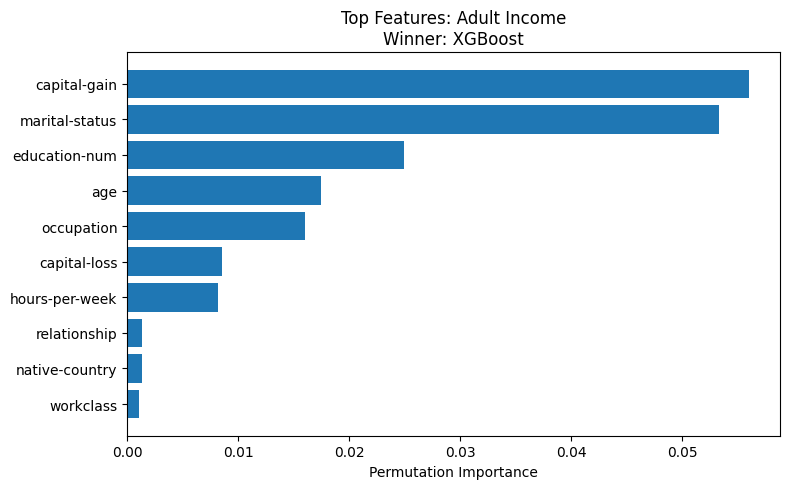

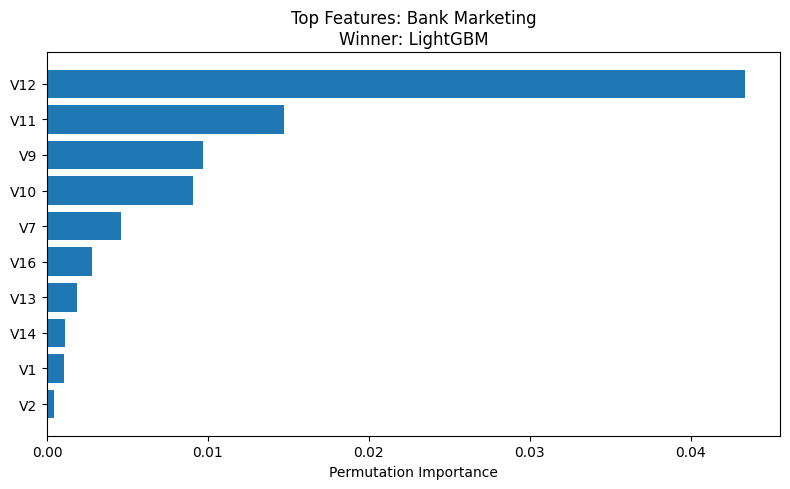

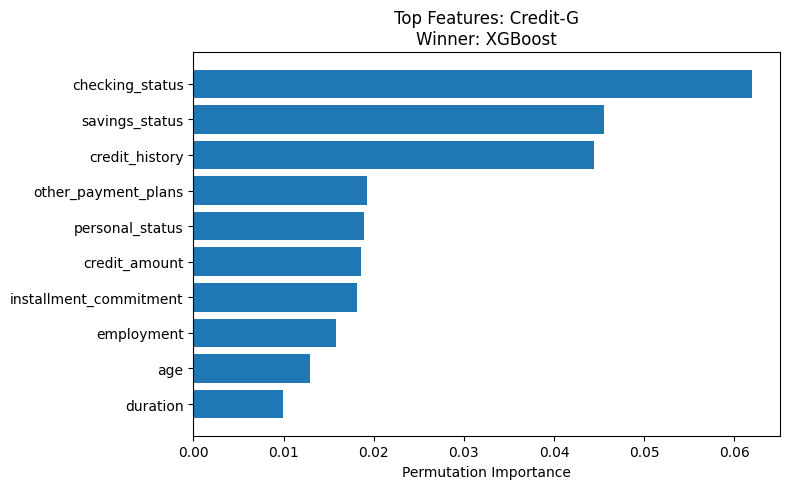

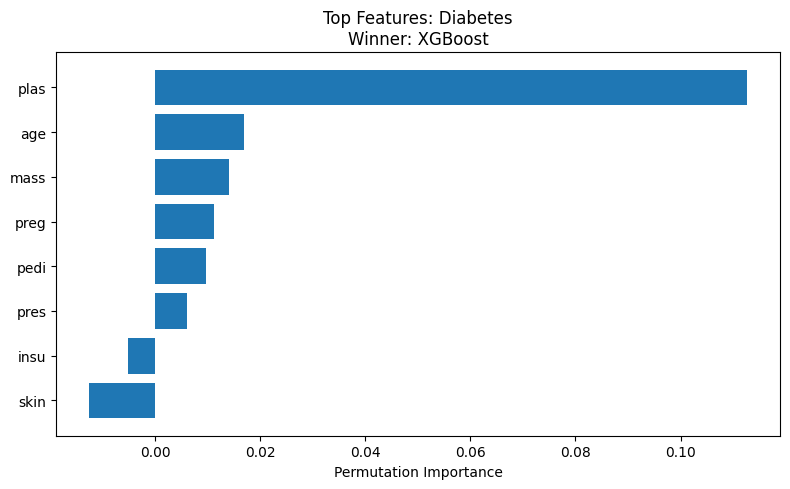

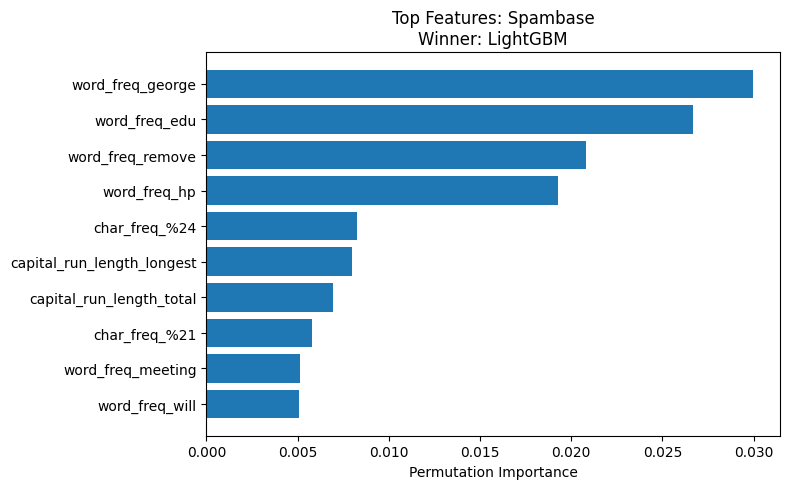

In [ ]:
feature_importance_results = {}
for _, row in best_per_dataset.iterrows():
    key = (row["Dataset"], row["Model"])
    artifact = trained_artifacts.get(key)
    if artifact is None: continue
    X_test, y_test, pipeline = artifact["X_test"], artifact["y_test"], artifact["pipeline"]
    X_sample = X_test.sample(min(1500,len(X_test)), random_state=RANDOM_STATE)
    y_sample = y_test.loc[X_sample.index]
    try:
        imp = permutation_importance(pipeline, X_sample, y_sample, scoring="f1_weighted", n_repeats=3, random_state=RANDOM_STATE, n_jobs=-1)
        imp_df = pd.DataFrame({"Feature":X_sample.columns,"Importance":imp.importances_mean}).sort_values("Importance", ascending=False)
        feature_importance_results[row["Dataset"]] = imp_df
        top = imp_df.head(10).sort_values("Importance")
        plt.figure(figsize=(8,5))
        plt.barh(top["Feature"], top["Importance"])
        plt.xlabel("Permutation Importance")
        plt.title(f"Top Features: {row['Dataset']}\nWinner: {row['Model']}")
        plt.tight_layout(); plt.show()
    except Exception as exc:
        print(f"Feature importance failed for {row['Dataset']}: {exc}")

# 🏁 So... Which Model Wins?

After benchmarking multiple algorithms across multiple datasets, we can finally compare them from different perspectives.

### 🥇 Best Average Rank

Which model most consistently occupies a strong position across datasets?

### ⭐ Highest Mean F1

Which model achieves the strongest average predictive performance?

### ⚡ Fastest Training

Which model reaches its results with the lowest average training cost?

These dimensions are intentionally kept separate.

Why?

Because:

**Performance ≠ Consistency ≠ Efficiency**

A model can be:

- highly accurate but computationally expensive,
- extremely fast but less accurate,
- or consistently strong without winning every individual dataset.

> **There may be no universal "best" model — only a model that is best for a particular objective and data environment.**

In [ ]:
overall_best = model_consistency.sort_values(["Mean_Rank","Mean_F1"], ascending=[True,False]).iloc[0]
highest_mean_f1 = model_consistency.sort_values("Mean_F1", ascending=False).iloc[0]
fastest_model = efficiency_df.sort_values("Mean_Training_Time").iloc[0]
summary_table = pd.DataFrame({
    "Research Dimension":["Best average rank across datasets","Highest mean F1 across datasets","Fastest average training","Datasets successfully evaluated","Model families evaluated"],
    "Result":[overall_best["Model"], highest_mean_f1["Model"], fastest_model["Model"], len(DATASETS), len(MODELS)]
})
display(summary_table)
print("Best average-rank model:", overall_best["Model"], "| Mean rank:", round(overall_best["Mean_Rank"],3))
print("Highest mean-F1 model:", highest_mean_f1["Model"], "| Mean F1:", round(highest_mean_f1["Mean_F1"],4))

,Research Dimension,Result
0,Best average rank across datasets,XGBoost
1,Highest mean F1 across datasets,XGBoost
2,Fastest average training,KNN
3,Datasets successfully evaluated,5
4,Model families evaluated,9


Best average-rank model: XGBoost | Mean rank: 1.6
Highest mean-F1 model: XGBoost | Mean F1: 0.8451


# 💡 What Did We Actually Learn?

This experiment started with a simple question:

> **Which machine learning model performs best?**

But benchmarking across multiple datasets changes the question.

The more interesting questions become:

> **Which models remain competitive when the data changes?**

> **Which models are stable across different train-test partitions?**

> **What computational cost accompanies predictive performance?**

> **Do dataset characteristics appear to influence model behaviour?**

> **Which features are most influential for the strongest models?**

The benchmark therefore moves beyond a simple leaderboard and becomes a study of **model behaviour across different data environments**.

### 🔬 The Bigger Picture

Machine learning does not have a universal champion.

Model performance is shaped by the interaction between:

**Algorithm × Dataset × Features × Target Structure × Computational Constraints**

And that is why benchmarking across diverse datasets can be more informative than declaring a winner from a single experiment.

# 🚧 Before We Draw Conclusions...

Every experiment has boundaries.

This study should therefore be interpreted as an **exploratory benchmark**, rather than a definitive ranking of every machine learning algorithm.

### ⚠️ Limitations

- 📚 The benchmark uses a limited selection of OpenML datasets.
- ⚙️ Hyperparameter configurations are largely default or lightly specified.
- 🔬 Dataset-performance relationships are exploratory rather than causal.
- 💻 Training times depend on the Kaggle/Colab execution environment.
- 🌐 Dataset retrieval depends on OpenML availability and Internet access.
- ⚖️ Predictive performance alone does not capture fairness, calibration, robustness, or domain suitability.

### 🚀 Future Research

The experiment could be extended with:

- A substantially larger dataset collection
- Automated hyperparameter optimisation
- Nested cross-validation
- Friedman/Nemenyi statistical tests
- Fairness analysis
- Calibration analysis
- Distribution-shift evaluation
- Robustness testing
- More extensive explainability methods

> **This notebook is not the end of the experiment. It is a reproducible starting point for a larger benchmarking study.**

## 💾 Save benchmark outputs

In [ ]:
profile_df.to_csv("dataset_profiles.csv", index=False)
results_df.to_csv("model_benchmark_results.csv", index=False)
best_per_dataset.to_csv("best_model_per_dataset.csv", index=False)
model_consistency.to_csv("cross_dataset_model_consistency.csv", index=False)
efficiency_df.to_csv("model_efficiency_summary.csv", index=False)
characteristic_correlation_df.to_csv("dataset_characteristics_vs_performance.csv", index=False)
if not failure_df.empty:
    failure_df.to_csv("benchmark_failures.csv", index=False)
print("Benchmark outputs saved successfully.")

Benchmark outputs saved successfully.


# 📚 References

**OpenML — Collections and Benchmarks**  
OpenML provides standardized datasets, metadata, benchmark suites, and programmatic access for reproducible machine-learning experimentation.


**Scikit-learn — Cross-validation: Evaluating Estimator Performance**  
Provides the theoretical and practical foundations for cross-validation and model evaluation.


**Scikit-learn — Cross-validation API: `cross_val_score`**  
Documentation for evaluating an estimator using cross-validation.


**Scikit-learn — Permutation Feature Importance**  
Documentation explaining permutation-based model inspection and feature importance.


**Scikit-learn — Permutation Importance API**  
Reference documentation for `sklearn.inspection.permutation_importance`.


Breiman, L. (2001). **Random Forests.**  
*Machine Learning, 45, 5–32.*

---

### 📝 Benchmarking Philosophy

This notebook follows the broader principle of evaluating machine-learning algorithms under standardized and reproducible experimental conditions rather than relying on a single dataset or isolated model result.

🙏🏻 Thank You!
If you found this notebook useful:

⭐ Upvote it

💬 Leave a comment

🔄 Fork it for your own research paper metadata project

👤 Follow my Kaggle profile

> Open to collaborations and suggestions.

Happy coding and happy dataset building!

![GIF](https://c.tenor.com/YVh75_Jav18AAAAd/tenor.gif)